In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("Adidas_dataset.csv")

In [4]:
df


,Order_ID,Order_Date,Region,Country,City,Product_Category,Product_Name,Gender,Sales_Channel,Units_Sold,Price_Per_Unit,Discount_%,Payment_Method,Customer_Rating,Total_Sales,Operating_Cost,Operating_Profit
0,10001,4/12/2024,South America,UK,Berlin,Apparel,Ultraboost,Men,Outlet,15,14541,37.0,Credit Card,5.0,218115,121841.48630,96273.513670
1,10002,12/14/2024,Europe,Germany,Toronto,Accessories,Ultraboost,Men,Retail Store,9,8818,33.0,Credit Card,2.0,79362,54954.05742,24407.942580
2,10003,9/27/2024,South America,UK,Toronto,Accessories,Stan Smith,Men,Outlet,6,4094,8.0,Credit Card,5.0,24564,14608.06302,9955.936981
3,10004,4/16/2024,North America,India,Sao Paulo,Apparel,Superstar,Men,Outlet,11,5478,29.0,Debit Card,5.0,60258,38741.49043,21516.509570
4,10005,3/12/2024,South America,USA,Berlin,Shoes,Adilette,Women,Online,7,4930,31.0,Debit Card,4.0,34510,25910.13604,8599.863961
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5095,12508,8/14/2024,South America,India,Toronto,Shoes,Tracksuit,Men,Outlet,7,6372,20.0,Credit Card,3.0,44604,31895.08391,12708.916090
5096,12333,9/4/2024,Europe,Canada,Toronto,Shoes,Adilette,Unisex,Outlet,6,2954,16.0,Debit Card,1.0,17724,13387.08094,4336.919061
5097,14715,11/9/2024,Europe,USA,Toronto,Shoes,Stan Smith,Women,Online,6,4092,25.0,UPI,3.0,24552,19192.43709,5359.562911
5098,10136,12/11/2024,South America,India,Sao Paulo,Accessories,Adilette,Women,Online,18,4557,29.0,Debit Card,4.0,82026,46056.89600,35969.104000


In [5]:
df.isnull().sum()

Order_ID              0
Order_Date            0
Region                0
Country               0
City                257
Product_Category      0
Product_Name          0
Gender                0
Sales_Channel         0
Units_Sold            0
Price_Per_Unit        0
Discount_%          256
Payment_Method        0
Customer_Rating     252
Total_Sales           0
Operating_Cost        0
Operating_Profit      0
dtype: int64

In [6]:
df["City"] = df["City"].fillna(df["City"].mode()[0])

In [7]:
df["Discount_%"] = df["Discount_%"].fillna(df["Discount_%"].mean())

In [8]:
df["Customer_Rating"] = df["Customer_Rating"].fillna(df["Customer_Rating"].median())

In [17]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"],errors = "coerce")
df["Year"] = df["Order_Date"].dt.year

In [18]:
df

,Order_ID,Order_Date,Region,Country,City,Product_Category,Product_Name,Gender,Sales_Channel,Units_Sold,Price_Per_Unit,Discount_%,Payment_Method,Customer_Rating,Total_Sales,Operating_Cost,Operating_Profit,Year
0,10001,2024-04-12,South America,UK,Berlin,Apparel,Ultraboost,Men,Outlet,15,14541,37.0,Credit Card,5.0,218115,121841.48630,96273.513670,2024
1,10002,2024-12-14,Europe,Germany,Toronto,Accessories,Ultraboost,Men,Retail Store,9,8818,33.0,Credit Card,2.0,79362,54954.05742,24407.942580,2024
2,10003,2024-09-27,South America,UK,Toronto,Accessories,Stan Smith,Men,Outlet,6,4094,8.0,Credit Card,5.0,24564,14608.06302,9955.936981,2024
3,10004,2024-04-16,North America,India,Sao Paulo,Apparel,Superstar,Men,Outlet,11,5478,29.0,Debit Card,5.0,60258,38741.49043,21516.509570,2024
4,10005,2024-03-12,South America,USA,Berlin,Shoes,Adilette,Women,Online,7,4930,31.0,Debit Card,4.0,34510,25910.13604,8599.863961,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5095,12508,2024-08-14,South America,India,Toronto,Shoes,Tracksuit,Men,Outlet,7,6372,20.0,Credit Card,3.0,44604,31895.08391,12708.916090,2024
5096,12333,2024-09-04,Europe,Canada,Toronto,Shoes,Adilette,Unisex,Outlet,6,2954,16.0,Debit Card,1.0,17724,13387.08094,4336.919061,2024
5097,14715,2024-11-09,Europe,USA,Toronto,Shoes,Stan Smith,Women,Online,6,4092,25.0,UPI,3.0,24552,19192.43709,5359.562911,2024
5098,10136,2024-12-11,South America,India,Sao Paulo,Accessories,Adilette,Women,Online,18,4557,29.0,Debit Card,4.0,82026,46056.89600,35969.104000,2024


In [19]:
df["Year"].unique()

array([2024], dtype=int32)

In [9]:
df.columns

Index(['Order_ID', 'Order_Date', 'Region', 'Country', 'City',
       'Product_Category', 'Product_Name', 'Gender', 'Sales_Channel',
       'Units_Sold', 'Price_Per_Unit', 'Discount_%', 'Payment_Method',
       'Customer_Rating', 'Total_Sales', 'Operating_Cost', 'Operating_Profit'],
      dtype='object')

In [10]:
a = df["Order_ID"].value_counts()

In [11]:
a

Order_ID
11577    2
14573    2
11726    2
12796    2
13372    2
        ..
11686    1
11685    1
11683    1
11682    1
15000    1
Name: count, Length: 5000, dtype: int64

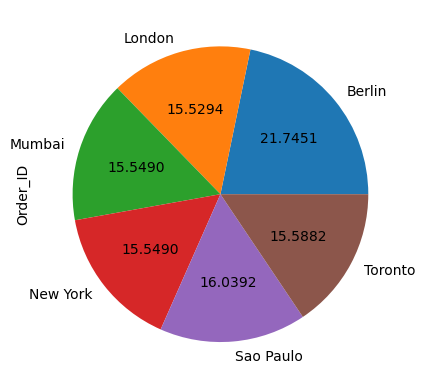

In [12]:
a = df.groupby("City")["Order_ID"].count().plot(kind="pie",autopct = "%.4f")


plt.show()


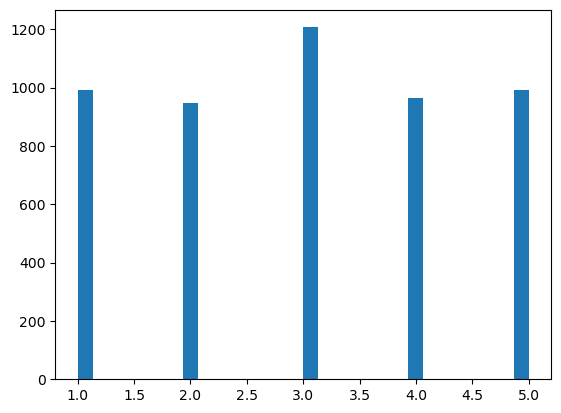

In [13]:
plt.hist(df["Customer_Rating"], bins=30) 
plt.show()

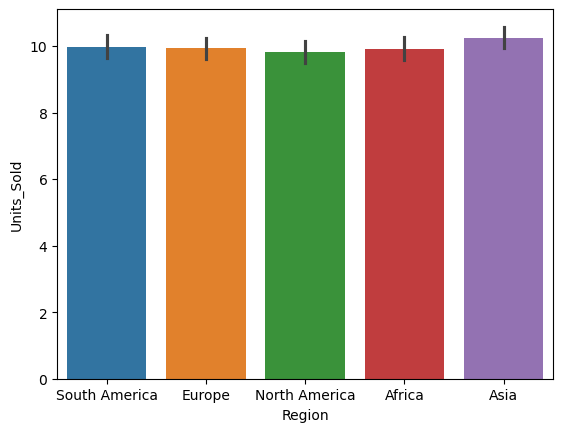

In [27]:
sns.barplot(x = df["Region"],y = df["Units_Sold"],hue=df["Region"])
plt.show()

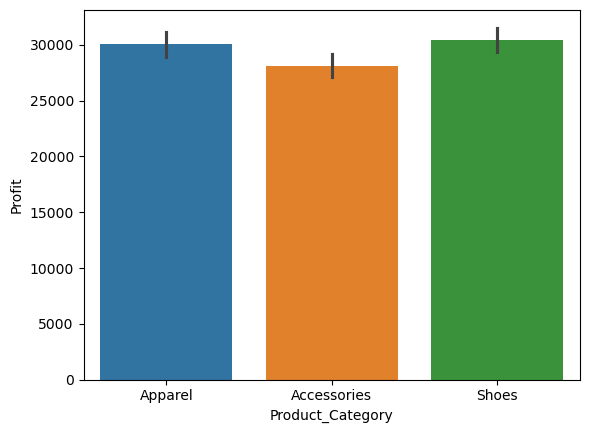

In [43]:
sns.barplot(x = df["Product_Category"],y = df["Operating_Profit"],hue = df["Product_Category"])
plt.ylabel("Profit")
plt.show()

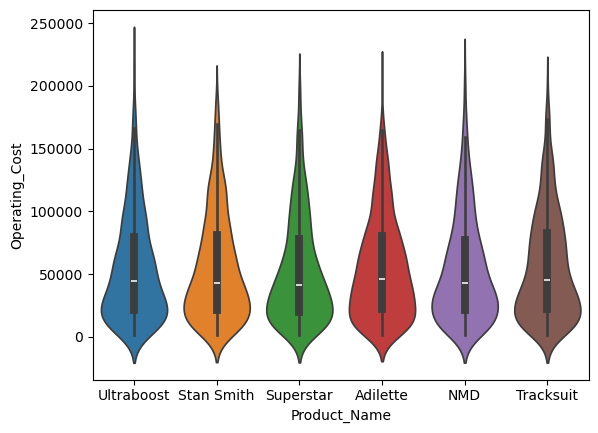

In [25]:
sns.violinplot(x="Product_Name", y="Operating_Cost",hue="Product_Name" ,data = df)
plt.show()


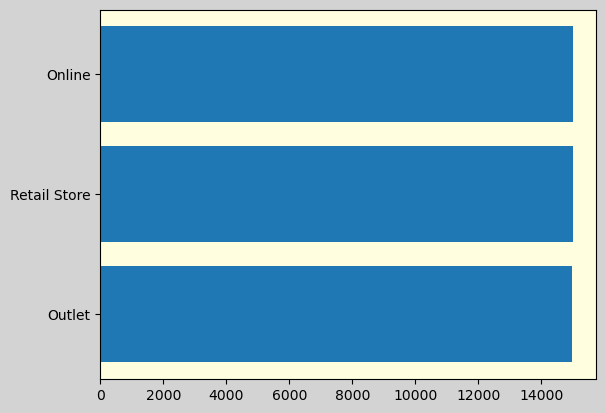

In [33]:
fig, ax = plt.subplots()

fig.patch.set_facecolor("lightgray")
ax.set_facecolor("lightyellow")

ax.barh(df["Sales_Channel"],df["Price_Per_Unit"])
plt.show()


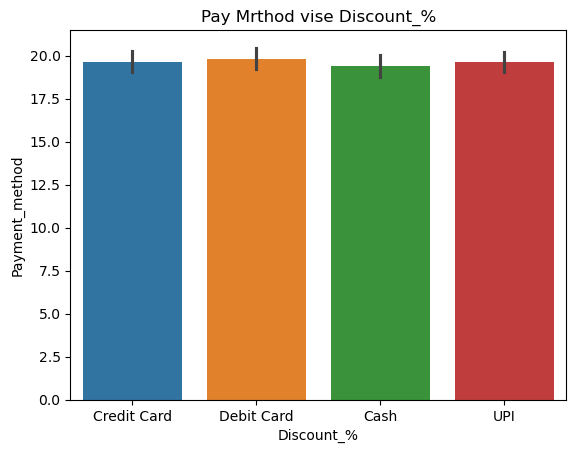

In [42]:
sns.barplot(x = df["Payment_Method"],y = df["Discount_%"],hue = df["Payment_Method"])
plt.title("Pay Mrthod vise Discount_%")
plt.xlabel("Discount_%")
plt.ylabel("Payment_method")
plt.show()